# ICD Report Generation

Bleed Air Valve Actuator Report


### Model-Specific Code (Do Not Modify)

This section contains code that is specific to the system model. It is updated only when the model is changed and should not require user modifications under normal circumstances.

If a new model is introduced, ensure this section is reviewed and updated as needed.


In [1]:
#!pip install --upgrade git+https://github.com/tkSDISW/Capella_Tools 
import capellambse.decl

from capella_tools import capellambse_helper


from IPython import display as diag_display
resources = {
    "HBTurboFan": "HBTurbFan/High Bypass Turbo Fan",
}
path_to_model = "../High Bypass Turbo Fan.aird"
model = capellambse.MelodyModel(path_to_model, resources=resources)





Load Embedding to locate the object by name.


In [2]:

from capella_tools  import capella_embeddings_manager

# Generate embeddings for all objects
model_embedding_manager = capella_embeddings_manager.EmbeddingManager()

embedding_file = "embeddings.json" 
model_embedding_manager.set_files( path_to_model , embedding_file)

model_embedding_manager.create_model_embeddings(model)

✅ EmbeddingManager initialized
🔐 API Key: Loaded from secrets
🌐 Base URL: Default
🤖 Model: gpt-4o
Loading embeddings
embeddings loaded.


Search for the component. 


In [3]:

selected_objects = model_embedding_manager.query_and_select_top_objects("Bleed Air Valve Actuator Logical Component", top_n=1)



This is a list of ranked Objects Based on Query:
Index: 0, Name: Bleed Air Valve Actuator, Similarity: 0.91, Type: LogicalComponent, Phase: Logical Architecture LA, Source: , Target: 



 📝 Generate Structured Input File 
.

In [4]:
#Workflow
from capella_tools import capellambse_yaml_manager
yaml_handler = capellambse_yaml_manager.CapellaYAMLHandler()
   
#Generate YAML for the logical component and append to the file
for object in  selected_objects : 
    yaml_handler.generate_yaml(model.by_uuid(object["uuid"]))  



#yaml_handler.display()
yaml_handler.generate_yaml_referenced_objects()
#yaml_handler.display()

yaml_handler.write_output_file()


## 🖼️ Generate Contextual Diagram




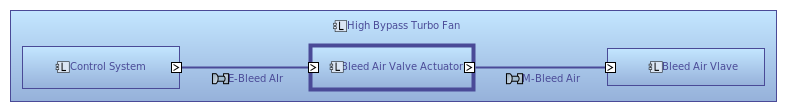

In [5]:
from capella_tools import capellambse_helper
from IPython import display as diag_display
from IPython.display import Markdown
for object in  selected_objects : 
    #print(object)
    if object["type"] == "Diagram" :
        diagram = model.by_uuid(object["uuid"])
        #display(diagram)
    else:
        obj = model.by_uuid(object["uuid"])
        capellambse_helper.display_context_diagram(obj)



In [6]:
prompt = """
Please analyze the yaml file and display the result as .html and Generate an Interface Control Document:
All Component Exchanges will have prefix P,M,E,I,H,F where P - Physical, M is Menchanical, E - Electrical, I - Information, H is Hydaulic, F is Fluid.
1. Describe the Component and it function. Elaborate with domain knowledge.
2. Describe each Component exchange using decoding the prefix and using its name and related functional exchange.
    Detail each functional exchange and functions is supports. 
    A report on all the requirement or properties related to the component exchange.
    Add a list of souces used for elaboration.
"""


In [7]:
import os
from openai import OpenAI
from IPython.core.display import HTML
from IPython.display import display, clear_output, Markdown
from capella_tools  import Open_AI_RAG_manager
  


# Step 1: Get YAML content
yaml_content = yaml_handler.get_yaml_content()

# Step 2: Invoke ChatGPT for analysis
analyzer = Open_AI_RAG_manager.ChatGPTAnalyzer(
    yaml_content=yaml_content,
    config_name="gpt-oss-120b"
)
analyzer.initial_prompt(prompt)
chatgpt_response = analyzer.get_response()


✅ ChatGPTAnalyzer initialized
🔐 API Key: Loaded from secrets
🌐 Base URL: https://api.siemens.com/llm
🤖 Model: gpt-oss-120b


**Your prompt:** 
Please analyze the yaml file and display the result as .html and Generate an Interface Control Document:
All Component Exchanges will have prefix P,M,E,I,H,F where P - Physical, M is Menchanical, E - Electrical, I - Information, H is Hydaulic, F is Fluid.
1. Describe the Component and it function. Elaborate with domain knowledge.
2. Describe each Component exchange using decoding the prefix and using its name and related functional exchange.
    Detail each functional exchange and functions is supports. 
    A report on all the requirement or properties related to the component exchange.
    Add a list of souces used for elaboration.
 Format the response in .html format.

**Token Usage Info:**

Tokens used: prompt=2211, completion=3206, total=5417

## ⚙️ Execute Followup Prompts

### Purpose
This cell executes the **follow up prompts** defined for analyzing the model. These prompts can be added by the note book user in addition to the default prompts

### What This Cell Does
- Use the structured input file (e.g., `capella_model.yaml`).
- Excutes the prompt defined in the cell.
- Outputs the results directly in the notebook.

### 🛠️ Instructions
1. Ensure the `capella_model.yaml` file is generated and up-to-date.
2. Run this cell to execute the default prompts.
3. Review the output to verify the accuracy and relevance of the analysis.

> 💡 **Tip:** Modify the promt to your needs.

In [8]:
#analyzer.follow_up_prompt("Review the Sensors and actuators associated with the Stage 3 diagram and recommend any that may be missing..")
#chatgpt_response = analyzer.get_response()




In [9]:
print("Done")

Done


# 